# Stiff ROBER problem -- training and evaluation

## The governing equations

The Robertson (ROBER) problem describes three species $y_1, y_2, y_3$ reaction which gives the ODE system

$$
\frac{dy_1}{dt} = -k_1 y_1 + k_3 y_2 y_3, \qquad
\frac{dy_2}{dt} = k_1 y_1 - k_2 y_2^2 - k_3 y_2 y_3, \qquad
\frac{dy_3}{dt} = k_2 y_2^2
$$

with $y_1(0)=1,\ y_2(0)=0,\ y_3(0)=0$ and $k_1=0.04,\ k_2=3\times10^7,\ k_3=10^4$.
Because $k_2/k_1 \sim 10^9$, the three species evolve on wildly different timescales --
this is what makes the problem "stiff", and why it needs a special solver (BDF) or a
special reduction (below) instead of a plain explicit integrator.

## The QSS (quasi-steady-state) assumption

$y_2$ builds up almost instantly and then stays extremely small for the rest of the
simulation. Its production and consumption rates are both large, but nearly equal --
so its *net* rate of change is tiny. The QSS assumption is to set that net rate to
zero, $dy_2/dt \approx 0$, and solve for $y_2$ algebraically instead of with an ODE:

$$
0 = k_1 y_1 - k_2 y_2^2 - k_3 y_2 y_3
\quad\Longrightarrow\quad
y_2 = \frac{-k_3 y_3 + \sqrt{(k_3 y_3)^2 + 4 k_1 k_2 y_1}}{2 k_2}
$$

This turns the stiff 3-ODE system into a much milder 2-ODE + 1-algebraic-equation
system (only $y_1, y_3$ are integrated; $y_2$ is recovered algebraically at every
time step). `stiff_pinn.py` uses exactly this reduction internally -- the network
only ever predicts $y_1, y_3$, and $y_2$ comes from the formula above. So once the
model is trained, the fair comparison is against the **QSS-reduced** reference
solution, not the raw stiff one (we compute both below, mainly to check that the
QSS assumption itself is accurate).

**References**

- Ji, Weiqi, et al. "Stiff-pinn: Physics-informed neural network for stiff chemical kinetics." *The Journal of Physical Chemistry A* 125.36 (2021): 8098-8106.
- Hao, Baoli, et al. "Stability in training PINNs for stiff PDEs: Why initial conditions matter." *arXiv preprint* arXiv:2404.16189 (2024).
- Yi, Yuxiao, et al. "An output scaling layer boosts deep neural networks for multiscale ODE systems." *arXiv preprint* arXiv:2512.05685 (2025).


## 1. Setup

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import vmap
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# float64 gives much more accurate gradients for this stiff problem than
# JAX's default float32 -- always turn this on before anything else runs
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_log_compiles", False)

import os
# Figures/animation saved here so they can be linked straight from README.md
ASSETS_DIR = "assets"
os.makedirs(ASSETS_DIR, exist_ok=True)

# --- problem constants, defined once and reused everywhere below ---
k1, k2, k3 = 0.04, 3e7, 1e4      # ROBER reaction rate constants (k2/k1 ~ 1e9 -> stiff)
t_min, t_max = 1.0e-5, 1.0e+5    # time domain
n_points = 5_000                 # points on the shared evaluation time grid
seed = 1

# Log-spaced grid: resolves both the fast (~1e-5 s) and slow (~1e5 s) dynamics
t_eval = jnp.geomspace(t_min, t_max, n_points)
t_eval_jax = t_eval


## 2. Reference solutions (full ODE vs. QSS-reduced)

In [2]:
def rober_rhs(time, y):
    """Right-hand side of the FULL 3-ODE ROBER system."""
    y1, y2, y3 = y
    return [-k1*y1 + k3*y2*y3, k1*y1 - k2*y2**2 - k3*y2*y3, k2*y2**2]


full_solution = solve_ivp( rober_rhs, (0.0, t_max), [1.0, 0.0, 0.0]
                          , method="BDF", t_eval=t_eval, rtol=1e-10, atol=1e-12 )

reference_full = jnp.asarray(full_solution.y.T)   # columns: y1, y2, y3

print("BDF mass-conservation error (max |y1+y2+y3-1|):",
      float(jnp.max(jnp.abs(reference_full.sum(axis=1) - 1))))


BDF mass-conservation error (max |y1+y2+y3-1|): 1.199040866595169e-14


In [3]:
def rober_rhs_qssa(time, y13):
    """Right-hand side of the QSS-REDUCED system: only y1 and y3 are ODEs.

    y2 is not integrated -- it is solved algebraically at every step from
    the QSS formula above, then substituted into the y1 and y3 equations.
    """
    y1, y3 = y13
    y2 = (-k3*y3 + np.sqrt((k3*y3)**2 + 4*k1*k2*y1)) / (2*k2)
    dy1 = -k1*y1 + k3*y2*y3
    dy3 = k2*y2**2
    return [dy1, dy3]


# The reduced system is much less stiff than the full one, so a plain
# explicit solver (RK45, i.e. Dopri5) works fine here -- no BDF needed.
reduced_solution = solve_ivp( rober_rhs_qssa, (0.0, t_max), [1.0, 0.0]
                             , method="RK45", t_eval=t_eval, rtol=1e-8, atol=1e-10 )

y1_qss, y3_qss = reduced_solution.y
y2_qss = (-k3*y3_qss + np.sqrt((k3*y3_qss)**2 + 4*k1*k2*y1_qss)) / (2*k2)

reference_qss = jnp.stack([jnp.asarray(y1_qss), jnp.asarray(y2_qss), jnp.asarray(y3_qss)], axis=1)

print("QSS mass-conservation error (max |y1+y2+y3-1|):",
      float(jnp.max(jnp.abs(reference_qss.sum(axis=1) - 1))))


QSS mass-conservation error (max |y1+y2+y3-1|): 3.6514763197548206e-05


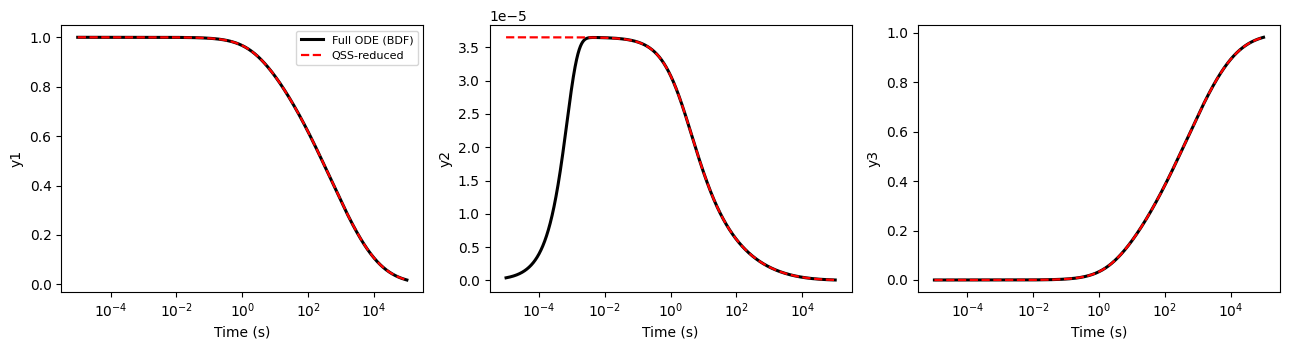

In [4]:
# Check the QSS assumption itself: the two reference curves should agree
# everywhere except briefly at the very start (the "induction period").
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for species, axis in enumerate(axes):
    axis.plot(t_eval, reference_full[:, species], "k-", lw=2.2, label="Full ODE (BDF)")
    axis.plot(t_eval, reference_qss[:, species], "r--", lw=1.6, label="QSS-reduced")
    axis.set_xscale("log")
    axis.set_xlabel("Time (s)")
    axis.set_ylabel(f"y{species+1}")
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()


## 3. Train Stiff-PINN

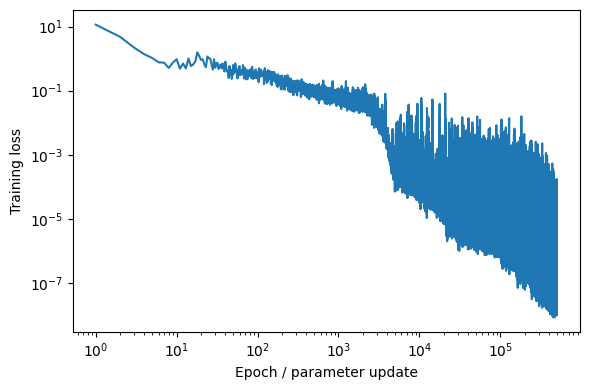

In [5]:
import stiff_pinn 

stiff_pinn_config = stiff_pinn.Config(
    updates=500_000, n_points=n_points, batch_size=32, learning_rate=1e-3,
    width=32, depth=3, t_min=t_min, t_max=t_max, k1=k1, k2=k2, k3=k3,
    seed=seed, beta=0.04,
)

stiff_pinn_results = stiff_pinn.train(stiff_pinn_config)

plt.figure(figsize=(6, 4))
plt.loglog(np.arange(1, len(stiff_pinn_results.loss) + 1), stiff_pinn_results.loss)
plt.xlabel("Epoch / parameter update")
plt.ylabel("Training loss")
plt.tight_layout()
plt.savefig(f"{ASSETS_DIR}/training_loss.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Compare against the QSS reference

In [6]:
# stiff_pinn's y2 comes from the same QSS formula, so we compare it
# against reference_qss (not reference_full) -- an apples-to-apples check.
prediction = vmap(lambda t: stiff_pinn.predict(stiff_pinn_results.model, t, stiff_pinn_config))(t_eval_jax)

error = prediction - reference_qss
rmse = jnp.sqrt(jnp.mean(error**2, axis=0))
relative = jnp.linalg.norm(error, axis=0) / (jnp.linalg.norm(reference_qss, axis=0) + 1e-30)
conservation = jnp.max(jnp.abs(prediction.sum(axis=1) - 1))

print(f"{'Species':<8} {'RMSE':>13} {'Relative L2':>13} {'Max |sum-1|':>14}")
print("-" * 51)
for species in range(3):
    print(f"{'y'+str(species+1):<8} {float(rmse[species]):13.5e} "
          f"{float(relative[species]):13.5e} {float(conservation):14.5e}")


Species           RMSE   Relative L2    Max |sum-1|
---------------------------------------------------
y1         1.89060e-04   2.32028e-04    1.34830e-03
y2         2.88518e-09   1.07589e-04    1.34830e-03
y3         4.26049e-04   9.80887e-04    1.34830e-03


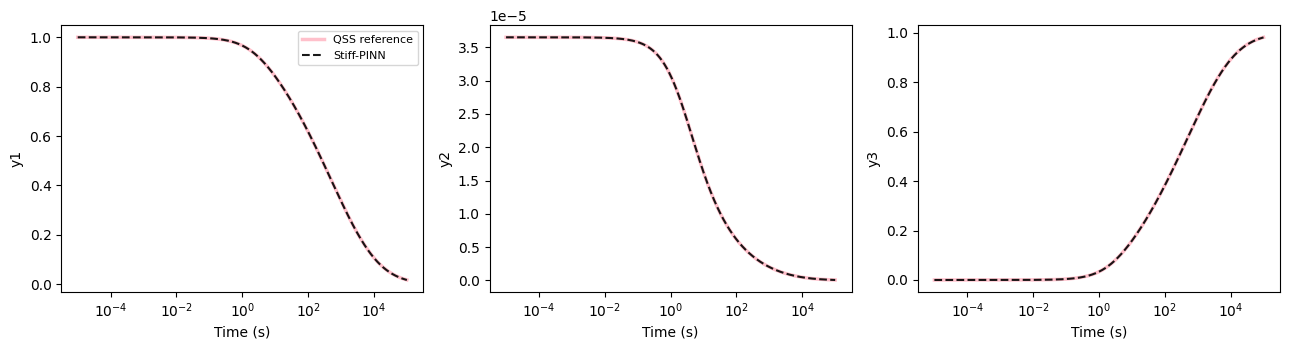

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for species, axis in enumerate(axes):
    axis.plot(t_eval, reference_qss[:, species], "-", lw=2.5, label="QSS reference", color='pink')
    axis.plot(t_eval_jax, prediction[:, species], "--", lw=1.5, label="Stiff-PINN", alpha=0.9, color='black')
    axis.set_xscale("log")
    axis.set_xlabel("Time (s)")
    axis.set_ylabel(f"y{species+1}")
axes[0].legend(fontsize=8)
fig.tight_layout()
fig.savefig(f"{ASSETS_DIR}/rober_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Training-progress movie

The idea: train the same model at a few increasing update budgets, predict with
each one, and animate through the sequence of predictions.

In [11]:
# from dataclasses import replace

# # smaller budgets to animate through; the final, largest budget is reused
# # from Section 3 below instead of training it again
# update_counts = [100, 1_000, 2_000, 3_000, 5_000, 8_000, 13_000, 21_000, 34_000, 55_000, 100_000]
# predictions_over_time = []

# for n in update_counts:
#     config_n = replace(stiff_pinn_config, updates=n)
#     result_n = stiff_pinn.train(config_n)
#     prediction_n = vmap(lambda t: stiff_pinn.predict(result_n.model, t, config_n))(t_eval_jax)
#     predictions_over_time.append(prediction_n)
#     print(f"updates = {n:>7}  ->  final training loss = {float(result_n.loss[-1]):.3e}")

# # reuse the fully-trained model and prediction from Section 3/4
# update_counts.append(stiff_pinn_config.updates)
# predictions_over_time.append(prediction)


In [10]:
# import matplotlib.animation as animation

# fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
# lines = []
# for species, axis in enumerate(axes):
#     axis.plot(t_eval, reference_qss[:, species], "-", lw=2.5, label="QSS reference", alpha=1, color='pink')
#     line, = axis.plot([], [], "--", lw=1.5, label="Stiff-PINN", alpha=0.9, color='black')
#     lines.append(line)
#     axis.set_xscale("log")
#     axis.set_xlabel("Time (s)")
#     axis.set_ylabel(f"y{species+1}")
# axes[0].legend(fontsize=8)
# title = fig.suptitle("")
# fig.tight_layout()


# def update_frame(frame_index):
#     frame_prediction = predictions_over_time[frame_index]
#     for species, line in enumerate(lines):
#         line.set_data(t_eval, frame_prediction[:, species])
#     title.set_text(f"Training updates: {update_counts[frame_index]:,}")
#     return lines + [title]


# FPS = 4  # frames per second, used both for the live preview and the saved GIF
# anim = animation.FuncAnimation(fig, update_frame, frames=len(update_counts), interval=1000 / FPS)

# gif_path = f"{ASSETS_DIR}/training_progress.gif"
# anim.save(gif_path, writer="pillow", fps=FPS)
# print(f"Saved animation to {gif_path}")

# plt.show()
# plt.close(fig)
